In [10]:
import Kea
from Kea.utils import plotting
from Kea.simulator import fbm
from Kea.statistics import statistics_base, moments
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra, per_spectra, corr_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive, corr
from Kea.fitting import fit_base

c = plotting.COLOR_CYCLE_6

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt

import numpy as np

D = 2
N = 64
L = 5.*np.pi
grid_dims = [N for _ in range(D)]
phys_dims = [L for _ in range(D)]

twopi = 2.*np.pi
dk = twopi/L
dx = L/N

/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:41: RuntimeWarning: divide by zero encountered in reciprocal
  pl = xx**(alphas[0])
/home/m/Documents/science_codes/Kea/Kea/utils/funcs.py:41: RuntimeWarning: divide by zero encountered in power
  pl = xx**(alphas[0])


(0.9, 1.1)

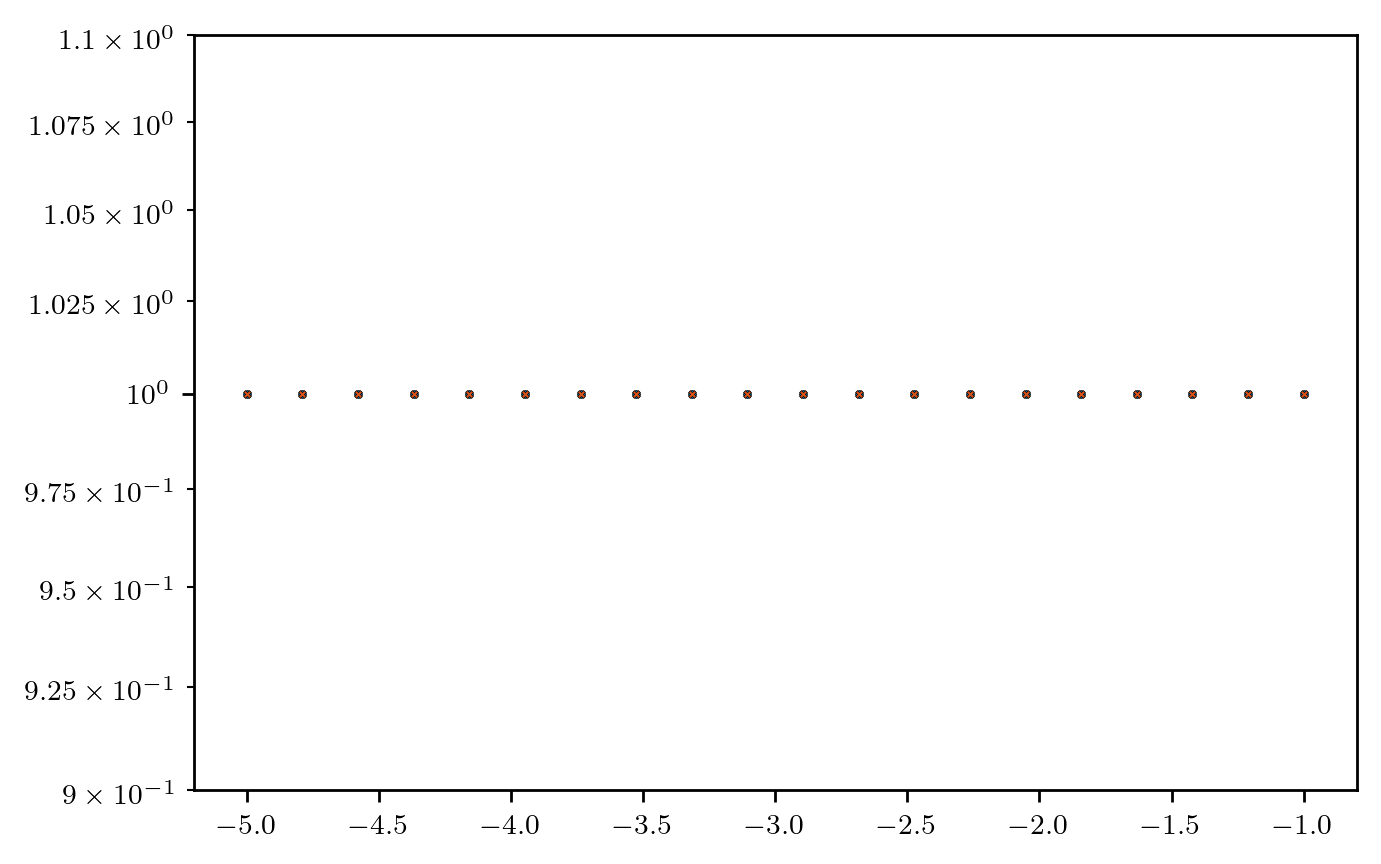

In [11]:
min, max = -(D+3.), -1.
NUM = 20
alphas = np.linspace(max, min, NUM)
np.random.seed(1234)
fields = []
for a in alphas:
    fields.append(fbm.create_fbm(grid_dims, phys_dims, (a,), (1.,)))
energies = []
for f in fields:
    energies.append(moments.var(f, lenn=phys_dims))
acfs = []
bin_acfs = []
for i, f in enumerate(fields):
    lv = statfunc_base.get_all_lagvecs([2*n for n in grid_dims])
    acf = corr.process_lags(f, f, lv, lenn=phys_dims, shape=[2*n for n in grid_dims], periodic=True)
    acfs.append(acf)

    lvm = statfunc_base.get_lagvec_magnitude_array([2*n for n in grid_dims]) * dx

    bin_l, bin_acf, w = statistics_base.bin_data(lvm, acf, bin_func=np.nanmean,
        cut_excess=True, nan_small=False, ignore_nan=False,
        min_bin=0., bin_loc='center')

    bin_acfs.append((bin_l, bin_acf, w))

    e_parsevals1 = acf[np.where(lvm == 0)]
    e_parsevals2 = bin_acf[0]

    plt.scatter(alphas[i], e_parsevals1/energies[i], marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')
    plt.scatter(alphas[i], e_parsevals2/energies[i], marker='X', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black')

plt.yscale('log')
plt.ylim((9e-1, 1.1e0))

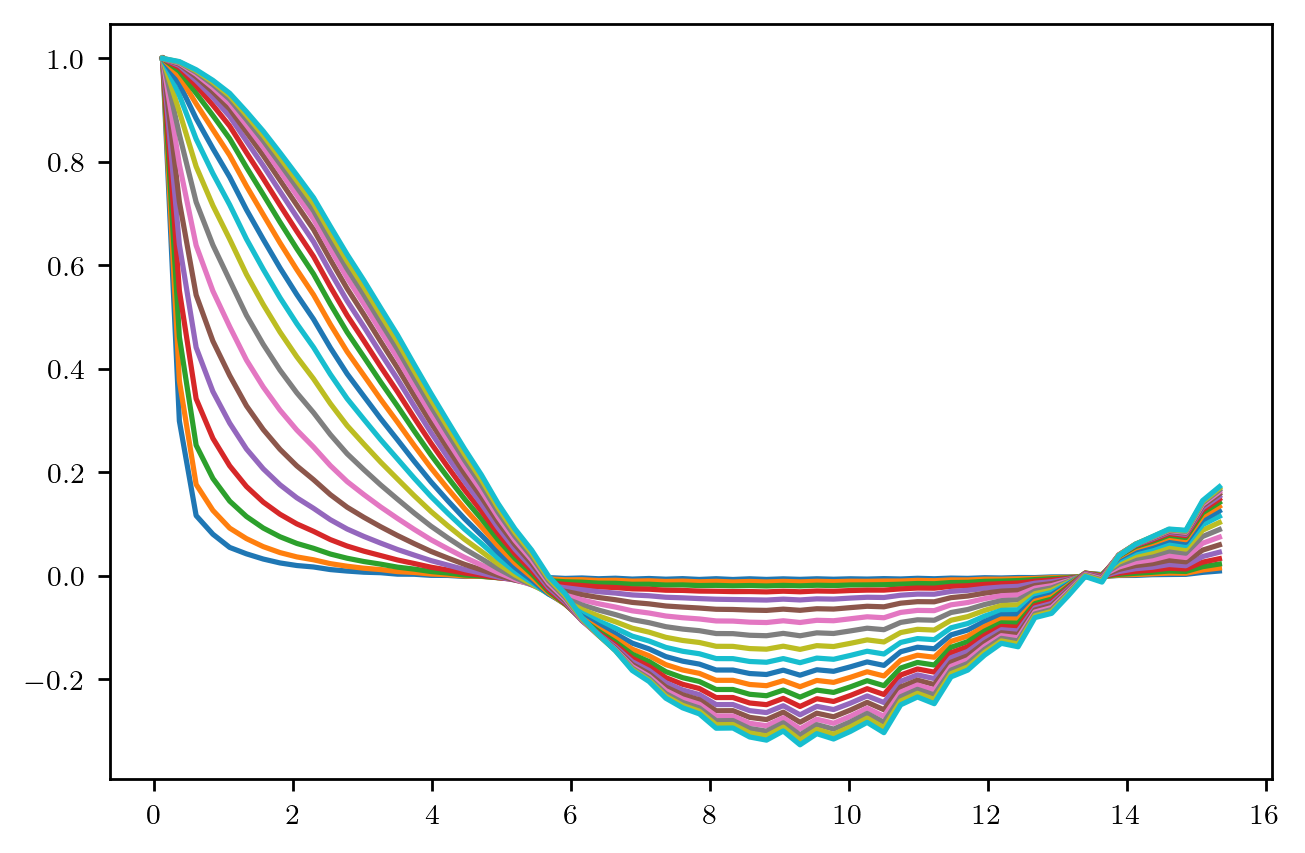

In [12]:
for lacf in bin_acfs:
    bin_l, bin_acf, w = lacf
    plt.plot(bin_l, bin_acf)

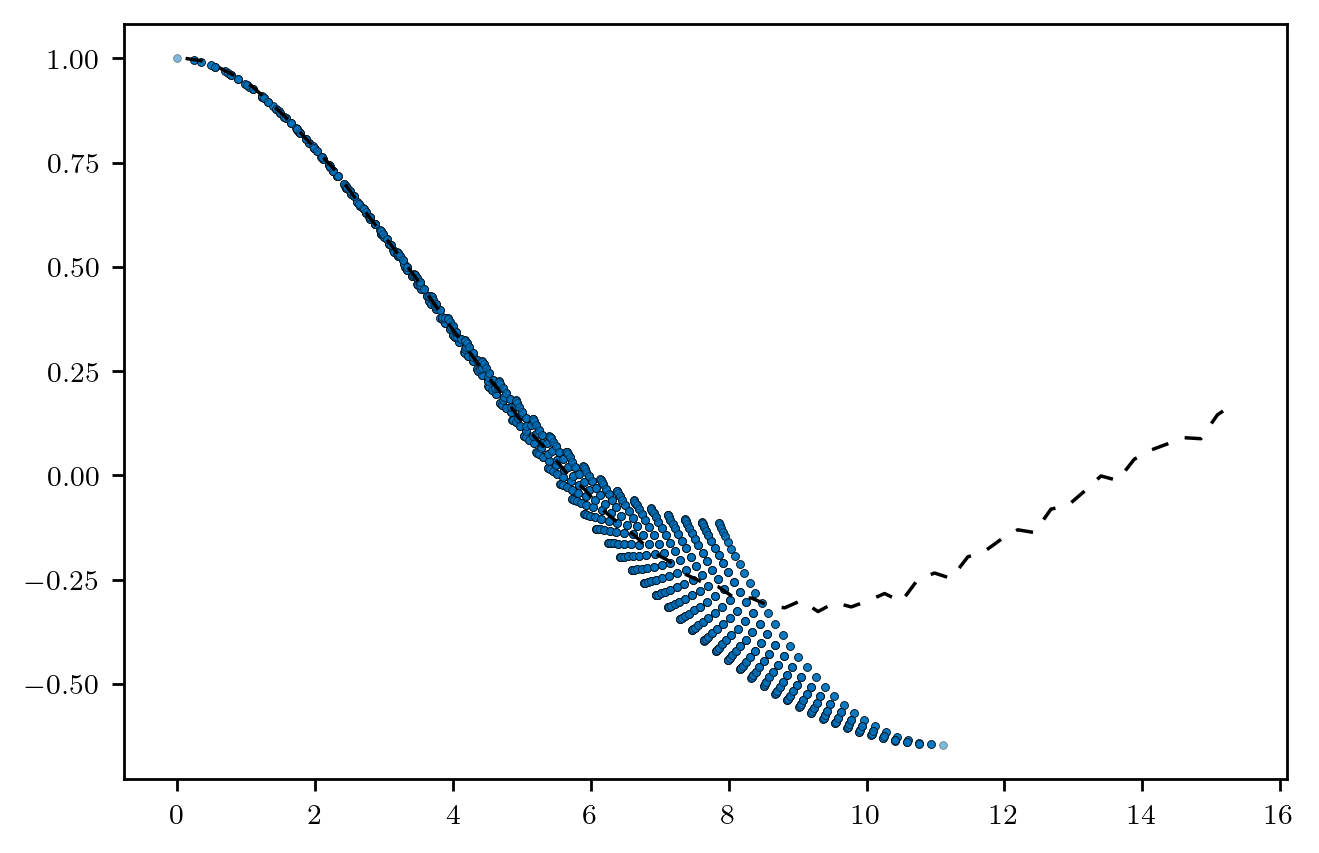

In [13]:
idx = -1

lvm = statfunc_base.get_lagvec_magnitude_array([2*n + 1 for n in grid_dims]) * dx
acf = acfs[idx]
lvm = statfunc_base.cut_at_lag(lvm, N//2)
acf = statfunc_base.cut_at_lag(acf, N//2)

bin_l, bin_acf, w = bin_acfs[idx]

plt.scatter(lvm, acf, marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black', alpha=0.5)
plt.plot(bin_l[:N], bin_acf[:N], linewidth=1., linestyle=(0, (5,5)), color='black')


In [28]:
IDX = 10
kmin = 2.*np.pi/L
kmax = N * np.pi / L
a = -alphas[IDX]
print(a, 2./(2.*np.pi) * (kmax**(2-a)/(2-a) - kmin**(2-a)/(2-a)))

3.1052631578947367 0.7756859947903237


In [29]:
from scipy.special import jv
import sympy as sp
sp.init_printing(use_latex='mathjax')

k = sp.symbols('k', postive=True, real=True)

a = -alphas[IDX]

sp_kmin = (2.*sp.pi/L)
sp_kmax = (sp.pi*N/L)

sp_E = sp.Piecewise(
    (0, k < sp_kmin),
    (0, k > sp_kmax),
    (k**(-a), True)
)

sig = sp.integrate(2. * (2. * sp.pi * k * sp_E) / (2.*sp.pi)**2, (k, 0., sp.oo))
Ef = sp_E / sig
Esig = sp.integrate(2. * (2. * sp.pi * k * Ef) / (2.*sp.pi)**2, (k, 0., sp.oo))

sp_l = sp.symbols('l', positive=True, real=True)

Ef2 = k**(-a) / Esig
sp_int2 = 2. * (2. * np.pi * k * Ef2) * sp.besselj(0, k*sp_l) / (2. * np.pi)**2

sp_int = 2. * (2. * sp.pi * k * Ef) * sp.besselj(0, k*sp_l) / (2. * sp.pi)**2
sp_acf = sp.integrate(sp_int, (k, 0., sp.oo))

#sp_E2 = sp.integrate(2. * (2. * np.pi)**2 * sp_acf * sp.besselj(0, k*sp_l) * (k*sp_l), (sp_l, dx, L))

display(sig)
display(Esig)
display(Ef)
display(sp_acf)
#display(sp_E2)


                  -2.10526315789474
8.63609201869651⋅π                 

1.00000000000000

                                    ⎛⎧        0           for k > 4.0743665431
                   2.10526315789474 ⎜⎪                                        
0.115793115431734⋅π                ⋅⎜⎨ -3.10526315789474                      
                                    ⎜⎪k                                       
                                    ⎝⎩                                        

5252⋅π ∨ k < 0.127323954473516⋅π⎞
                                ⎟
                                ⎟
 otherwise                      ⎟
                                ⎠

                      ┌─  ⎛  -0.552631578947368   │                    2  2⎞  
- 0.0221789047506019⋅ ├─  ⎜                       │ -4.15011568199016⋅π ⋅l ⎟ +
                     1╵ 2 ⎝0.447368421052632, 1.0 │                        ⎠  

                  ┌─  ⎛  -0.552631578947368   │                       2  2⎞
 1.0221789047506⋅ ├─  ⎜                       │ -0.00405284734569351⋅π ⋅l ⎟
                 1╵ 2 ⎝0.447368421052632, 1.0 │                           ⎠

246.73945320250942
[-2.98716262  0.22068386] 3.1052631578947367


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))


(1e-05, 100.0)

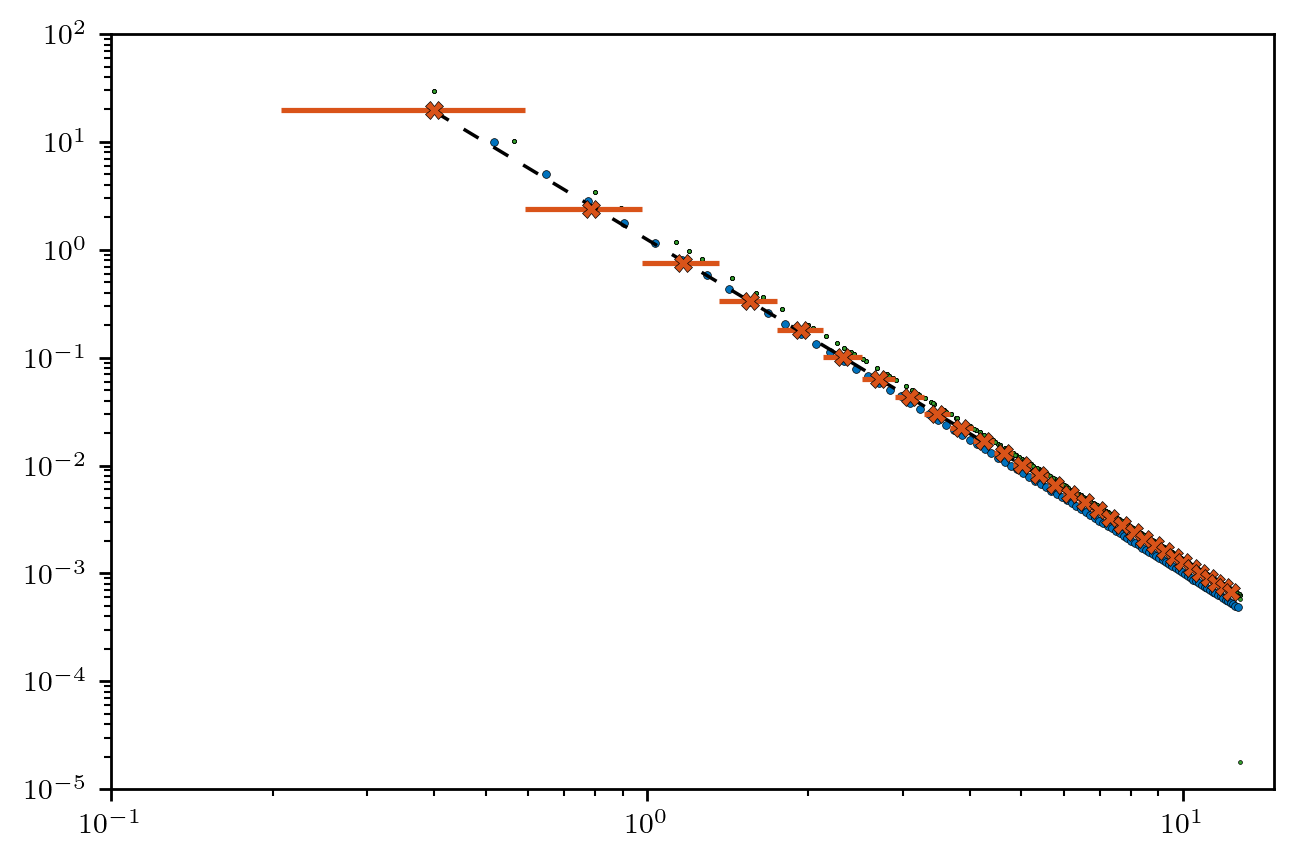

In [30]:
lam_E = sp.lambdify(k, Ef, modules=['scipy', 'numpy', 'mpmath'])
for _k in np.linspace(0., np.pi*N/L, 100):
    plt.scatter(_k, lam_E(_k), marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')

kD, fekD = per_spectra.modal_spectrum(fields[IDX], lenn=phys_dims)
print(np.nansum(fekD))
km, fekm, width = statistics_base.bin_data(spectra_base.wavenumber_mesh(kD), fekD,
    bin_func=np.nanmean, min_bin=dk, max_bin=None,
    ignore_nan=False, norm_bin_size=True, bin_loc='left',
    cut_excess=True, nan_small=False)

fekm = fekm * width

plt.scatter(spectra_base.wavenumber_mesh(kD), fekD, marker='.', s=5., color=c[2], zorder=0, linewidth=0.2, edgecolor='black')

plt.scatter(km, fekm, marker='X', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black')
plt.errorbar(km, fekm, xerr=width/2., linestyle='None', marker='X', markersize=5., color=c[1], zorder=2, markeredgewidth=0.2, markeredgecolor='black')#, marker='X', s=5., color=c[1], zorder=2, linewidth=0.2, edgecolor='black')

z, xx, p = fit_base.fit_powerlaw(km, fekm, kmin, kmax)
print(z, a)

plt.plot(xx, p, linewidth=1., linestyle=(0, (5,5)), color='black')

plt.loglog()

plt.xlim((kmin-0.3, (N+10)*np.pi/L))
plt.ylim((1e-5, 1e2))

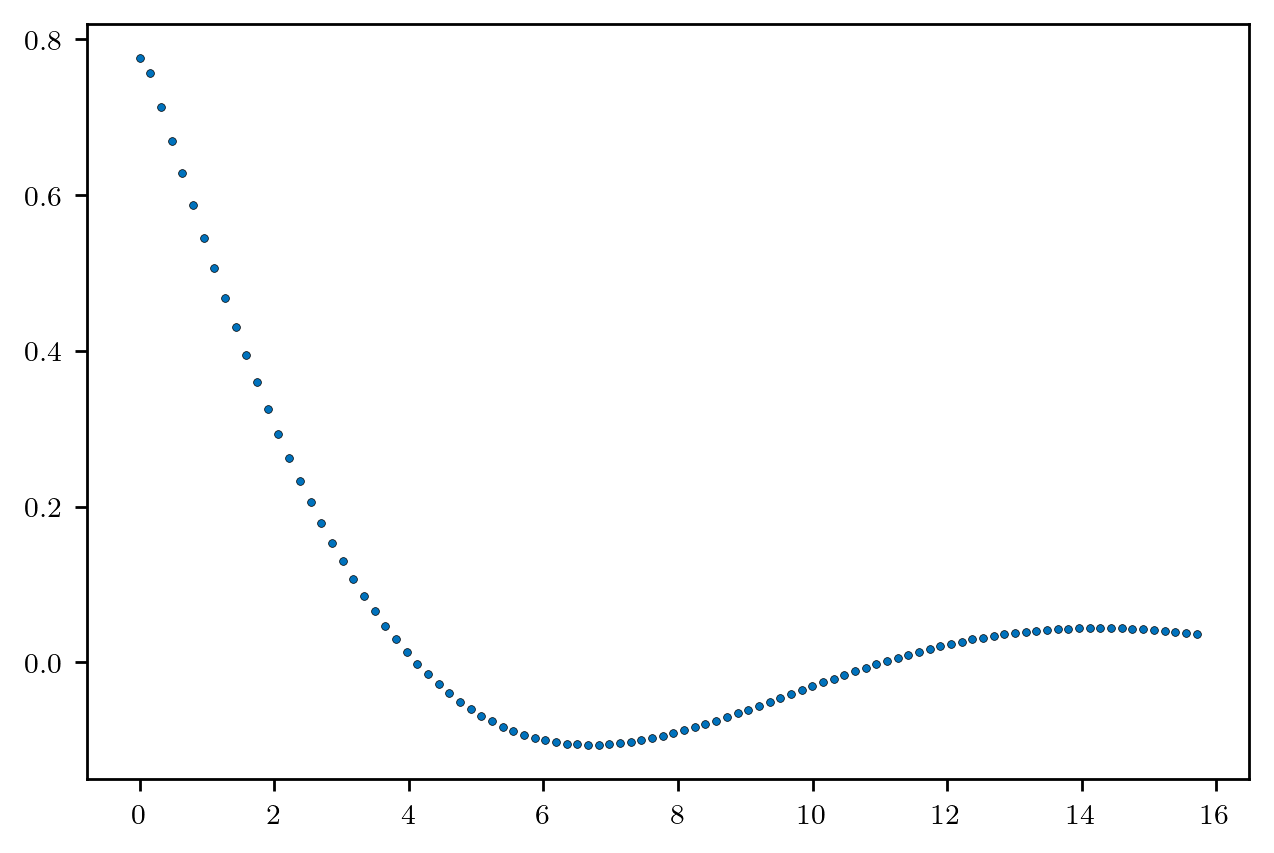

In [31]:
lam_int = sp.lambdify((k, sp_l), sp_int2, modules=['scipy', 'numpy'])

from scipy.integrate import quad

def integrand(x, l):
    return lam_int(x, l)

for _l in np.linspace(0., L, 100):
    ii = quad(integrand, kmin, kmax, args=(_l,))[0]
    plt.scatter(_l, ii, marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')

#for _k in np.linspace(0., np.pi*N/L, 100):
#plt.scatter(_k, lam_E(_k), marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')

(-0.1, 15.807963267948965)

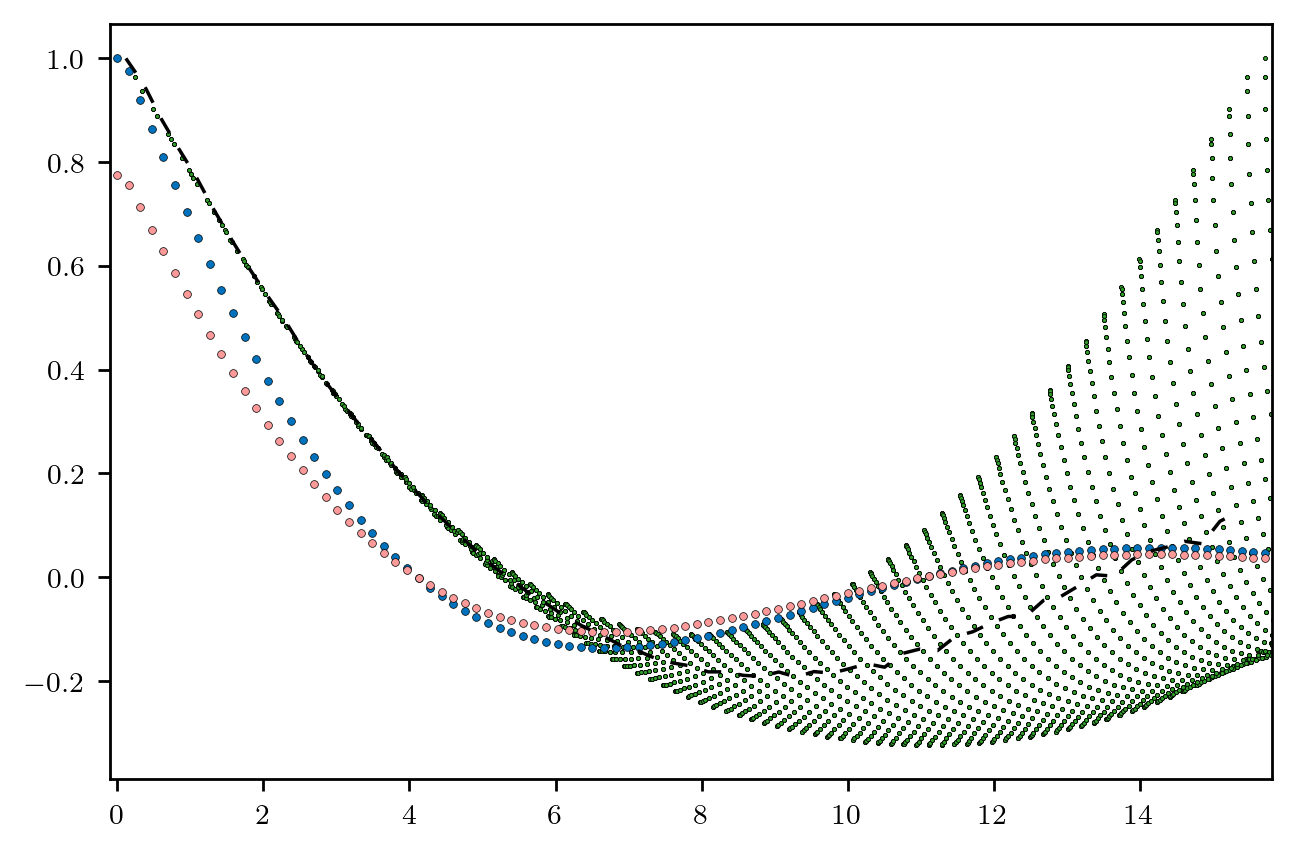

In [32]:

lam_acf = sp.lambdify(sp_l, sp_acf, modules=['scipy', 'numpy', 'mpmath'])
for _l in np.linspace(0., L, 100):
    plt.scatter(_l, lam_acf(_l), marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')

for _l in np.linspace(0., L, 100):
    ii = quad(integrand, kmin, kmax, args=(_l,))[0]
    plt.scatter(_l, ii, marker='o', s=5., color=c[3], zorder=2, linewidth=0.2, edgecolor='black')

lvm = statfunc_base.get_lagvec_magnitude_array([2*n + 1 for n in grid_dims]) * dx
acf = acfs[IDX]
lvm = statfunc_base.cut_at_lag(lvm, N)
acf = statfunc_base.cut_at_lag(acf, N)

bin_l, bin_acf, w = bin_acfs[IDX]

plt.scatter(lvm, acf, marker='.', s=5., color=c[2], zorder=0, linewidth=0.2, edgecolor='black')
plt.plot(bin_l, bin_acf, linewidth=1., linestyle=(0, (5,5)), color='black')
plt.xlim((0-0.1, L+0.1))